In [33]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import lightgbm as lgb

warnings.filterwarnings('ignore')

In [34]:
DATA_DIR = Path('.') 

OUTPUT_1500 = 'clean_center1500.csv'
OUTPUT_2900 = 'clean_center2900.csv'

COMMON_WAVE_1500 = np.linspace(930.0, 2000.0, num=1000)
COMMON_WAVE_2900 = np.linspace(2600.0, 3200.0, num=1000) 

TARGETS = ['endo', 'exo', 'control']
REGIONS = ['cortex', 'striatum', 'cerebellum', 'hippocampus']

def parse_metadata(filename):
    name_lower = filename.lower()
    
    target = 'unknown'
    for t in TARGETS:
        if t in name_lower:
            target = t
            break
            
    region = 'unknown'
    for r in REGIONS:
        if r in name_lower:
            region = r
            break
            
    if 'center1500' in name_lower:
        center = 'center1500'
    elif 'center2900' in name_lower:
        center = 'center2900'
    else:
        center = 'unknown'
        
    file_id = Path(filename).stem
    return target, region, center, file_id

def process_file(filepath, common_wave, is_first_file, output_csv):
    df = pd.read_csv(filepath, sep=r'\s+', skiprows=1, names=['X', 'Y', 'Wave', 'Intensity'])
    
    unique_coords = df[['X', 'Y']].drop_duplicates()
    n_pixels = len(unique_coords)
    n_total_rows = len(df)
    n_waves = n_total_rows // n_pixels
    
    file_wave = df['Wave'].values[:n_waves]
    
    if file_wave[0] > file_wave[-1]:
        file_wave = file_wave[::-1]
        intensity_matrix = df['Intensity'].values.reshape(n_pixels, n_waves)[:, ::-1]
    else:
        intensity_matrix = df['Intensity'].values.reshape(n_pixels, n_waves)

    interpolator = interp1d(file_wave, intensity_matrix, axis=1, kind='linear', 
                            bounds_error=False, fill_value="extrapolate")
    interpolated_intensities = interpolator(common_wave)
    
    target, region, center, file_id = parse_metadata(filepath.name)
    
    wide_df = pd.DataFrame({
        'file_id': [file_id] * n_pixels,
        'target': [target] * n_pixels,
        'region': [region] * n_pixels,
        'X': unique_coords['X'].values,
        'Y': unique_coords['Y'].values
    })
    
    wave_cols = [str(round(w, 1)) for w in common_wave]
    intensity_df = pd.DataFrame(interpolated_intensities, columns=wave_cols)
    final_df = pd.concat([wide_df, intensity_df], axis=1)
    
    final_df.to_csv(output_csv, mode='a', index=False, header=is_first_file)

if os.path.exists(OUTPUT_1500): os.remove(OUTPUT_1500)
if os.path.exists(OUTPUT_2900): os.remove(OUTPUT_2900)

all_files = list(DATA_DIR.rglob('*.txt'))

first_1500 = True
first_2900 = True

for filepath in tqdm(all_files, desc="Обработка файлов"):
    if 'center1500' in filepath.name.lower():
        process_file(filepath, COMMON_WAVE_1500, first_1500, OUTPUT_1500)
        first_1500 = False
    elif 'center2900' in filepath.name.lower():
        process_file(filepath, COMMON_WAVE_2900, first_2900, OUTPUT_2900)
        first_2900 = False

Обработка файлов:   0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/62965 [00:00<?, ?it/s]

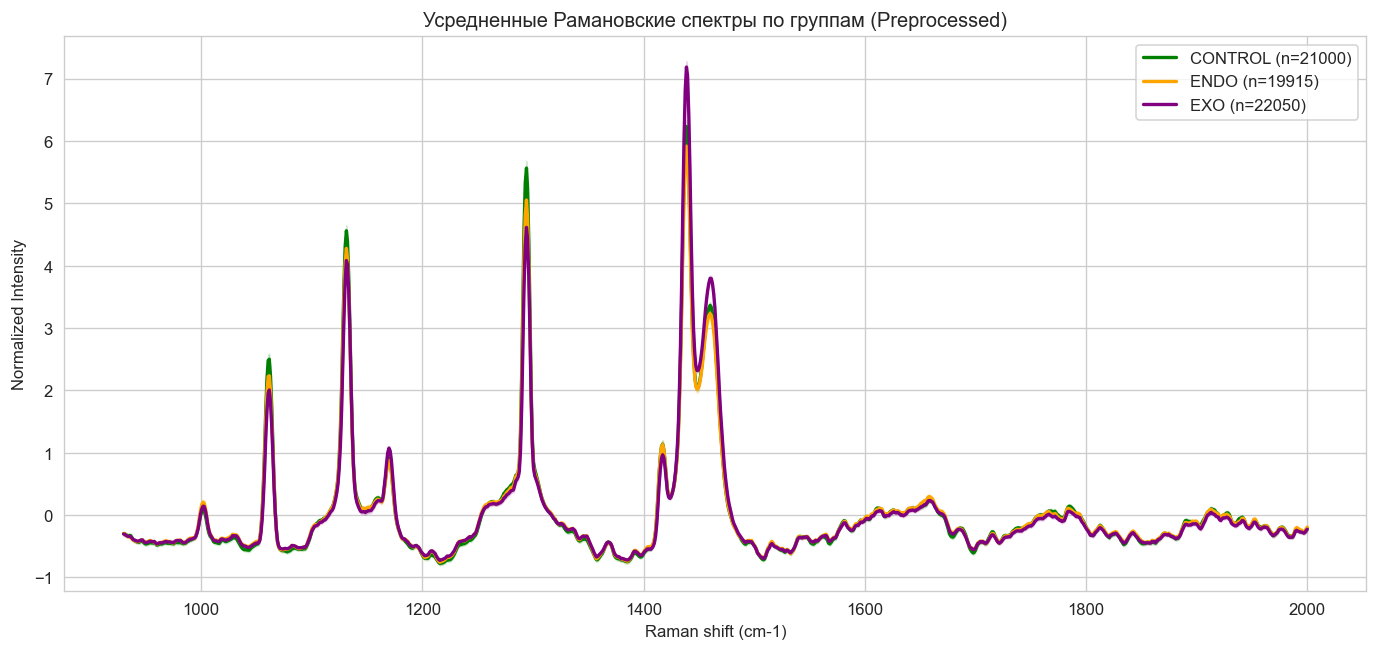

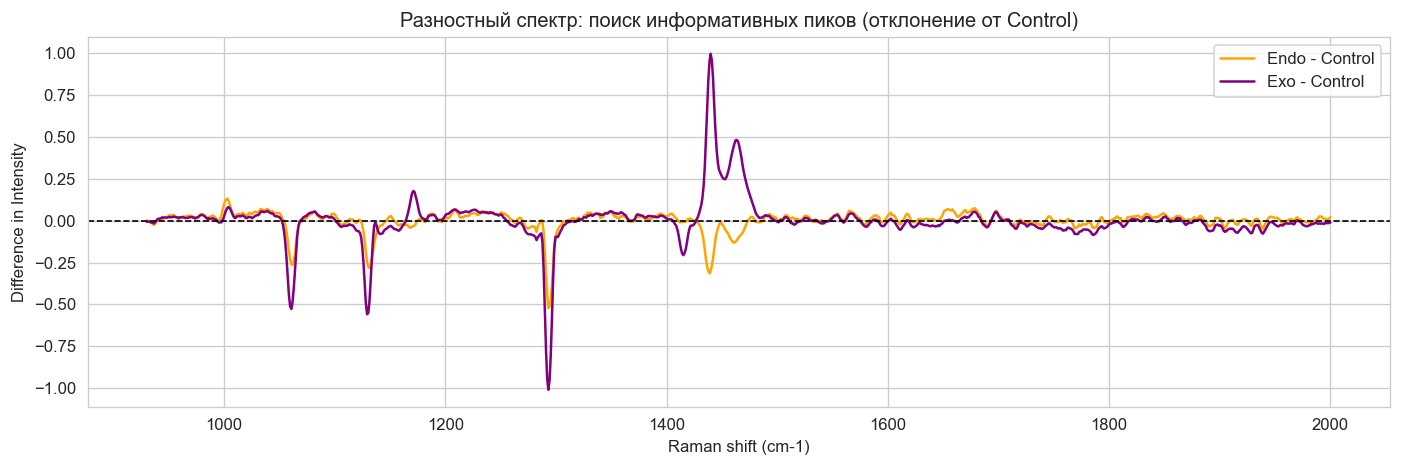

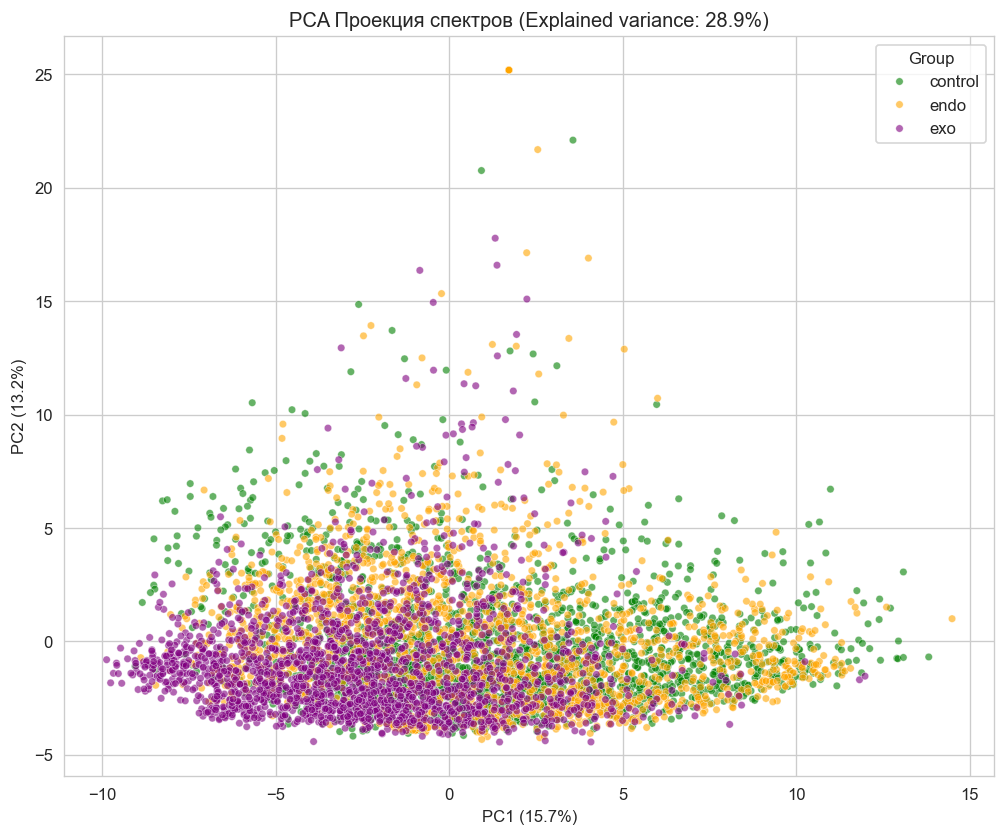

In [35]:
plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

df = pd.read_csv('clean_center1500.csv')

meta_cols = ['file_id', 'target', 'region', 'X', 'Y']
wave_cols = [c for c in df.columns if c not in meta_cols]

meta_df = df[meta_cols].copy()
spectra_matrix = df[wave_cols].values
waves = np.array(wave_cols, dtype=float)

def baseline_als(y, lam=10**5, p=0.01, niter=10):
    L = len(y)
    D = sparse.diags([1,-2,1],[0,-1,-2], shape=(L,L-2))
    D = lam * D.dot(D.transpose())
    w = np.ones(L)
    for i in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        Z = W + D
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1-p) * (y < z)
    return z

def preprocess_spectra(spectra):
    n_samples = spectra.shape[0]
    processed = np.zeros_like(spectra)
    
    spectra_clean = np.nan_to_num(spectra, nan=0.0, posinf=0.0, neginf=0.0)
    
    for i in tqdm(range(n_samples)):
        y = spectra_clean[i, :]
        if np.all(y == 0): continue
            
        baseline = baseline_als(y, lam=10**5, p=0.01)
        y_corrected = y - baseline
        
        processed[i, :] = savgol_filter(y_corrected, window_length=11, polyorder=3, mode='nearest')
        
    mean_vals = processed.mean(axis=1, keepdims=True)
    std_vals = processed.std(axis=1, keepdims=True)
    std_vals[std_vals == 0] = 1 
    
    processed_snv = (processed - mean_vals) / std_vals
    processed_snv = np.nan_to_num(processed_snv, nan=0.0)
    
    return processed_snv

spectra_processed = preprocess_spectra(spectra_matrix)

df_clean = meta_df.copy()
df_clean[wave_cols] = spectra_processed
df_clean.to_csv('ready_for_ML_1500.csv', index=False)

plt.figure(figsize=(14, 6))
colors = {'control': 'green', 'endo': 'orange', 'exo': 'purple', 'unknown': 'gray'}

for target in ['control', 'endo', 'exo']:
    class_mask = meta_df['target'] == target
    if not class_mask.any(): continue 
        
    class_spectra = spectra_processed[class_mask]
    mean_spectrum = class_spectra.mean(axis=0)
    
    std_spectrum = class_spectra.std(axis=0) * 0.1 
    
    plt.plot(waves, mean_spectrum, label=f'{target.upper()} (n={len(class_spectra)})', 
             color=colors.get(target, 'blue'), linewidth=2)
    plt.fill_between(waves, mean_spectrum - std_spectrum, mean_spectrum + std_spectrum, 
                     color=colors.get(target, 'blue'), alpha=0.15)

plt.title("Усредненные Рамановские спектры по группам (Preprocessed)")
plt.xlabel("Raman shift (cm-1)")
plt.ylabel("Normalized Intensity")
plt.legend()
plt.show()

if ('control' in meta_df['target'].values) and ('endo' in meta_df['target'].values) and ('exo' in meta_df['target'].values):
    mean_control = spectra_processed[meta_df['target'] == 'control'].mean(axis=0)
    mean_endo = spectra_processed[meta_df['target'] == 'endo'].mean(axis=0)
    mean_exo = spectra_processed[meta_df['target'] == 'exo'].mean(axis=0)

    plt.figure(figsize=(14, 4))
    plt.plot(waves, mean_endo - mean_control, label='Endo - Control', color='orange', linewidth=1.5)
    plt.plot(waves, mean_exo - mean_control, label='Exo - Control', color='purple', linewidth=1.5)

    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title("Разностный спектр: поиск информативных пиков (отклонение от Control)")
    plt.xlabel("Raman shift (cm-1)")
    plt.ylabel("Difference in Intensity")
    plt.legend()
    plt.show()
else:
    print("Невозможно построить разностный график: отсутствуют некоторые классы.")

pca = PCA(n_components=2)

sample_indices = []
for target in ['control', 'endo', 'exo']:
    idx = np.where(meta_df['target'] == target)[0]
    if len(idx) > 0:
        sample_indices.extend(np.random.choice(idx, min(2000, len(idx)), replace=False))

sample_indices = np.array(sample_indices)

pca_result = pca.fit_transform(spectra_processed[sample_indices])
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['target'] = meta_df.iloc[sample_indices]['target'].values

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='target', data=pca_df, palette=colors, alpha=0.6, s=20)
plt.title(f"PCA Проекция спектров (Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title='Group')
plt.show()

  0%|          | 0/63490 [00:00<?, ?it/s]

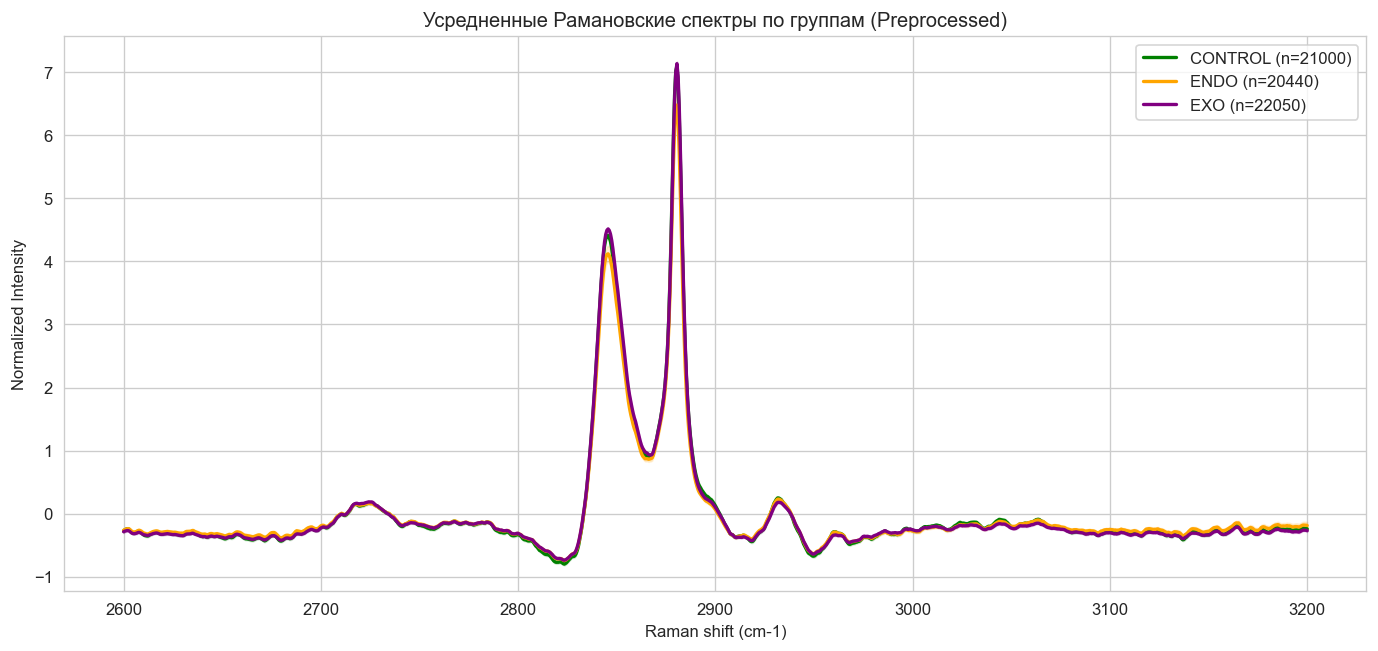

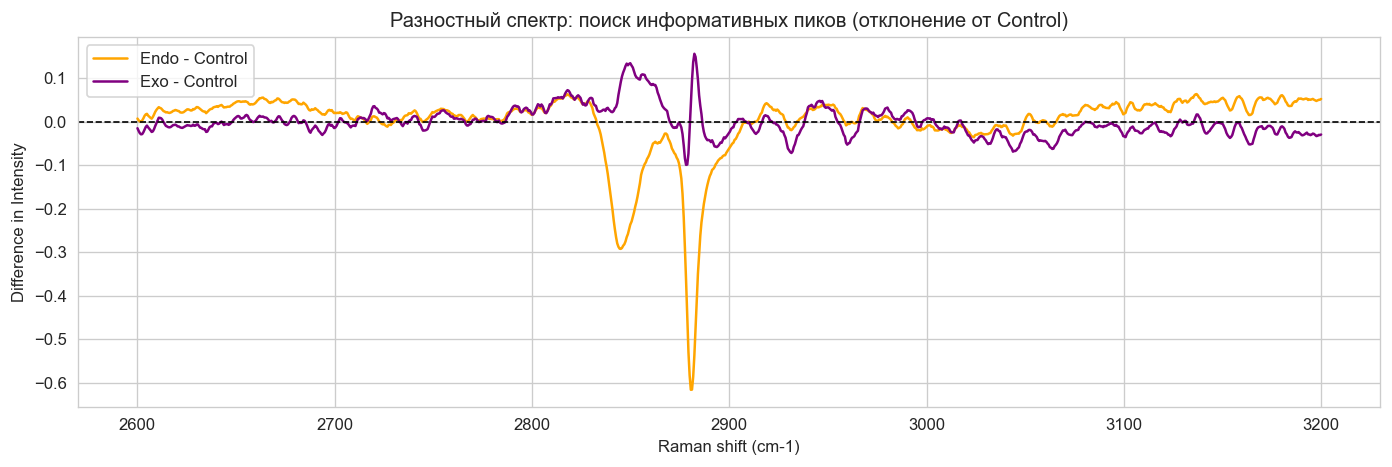

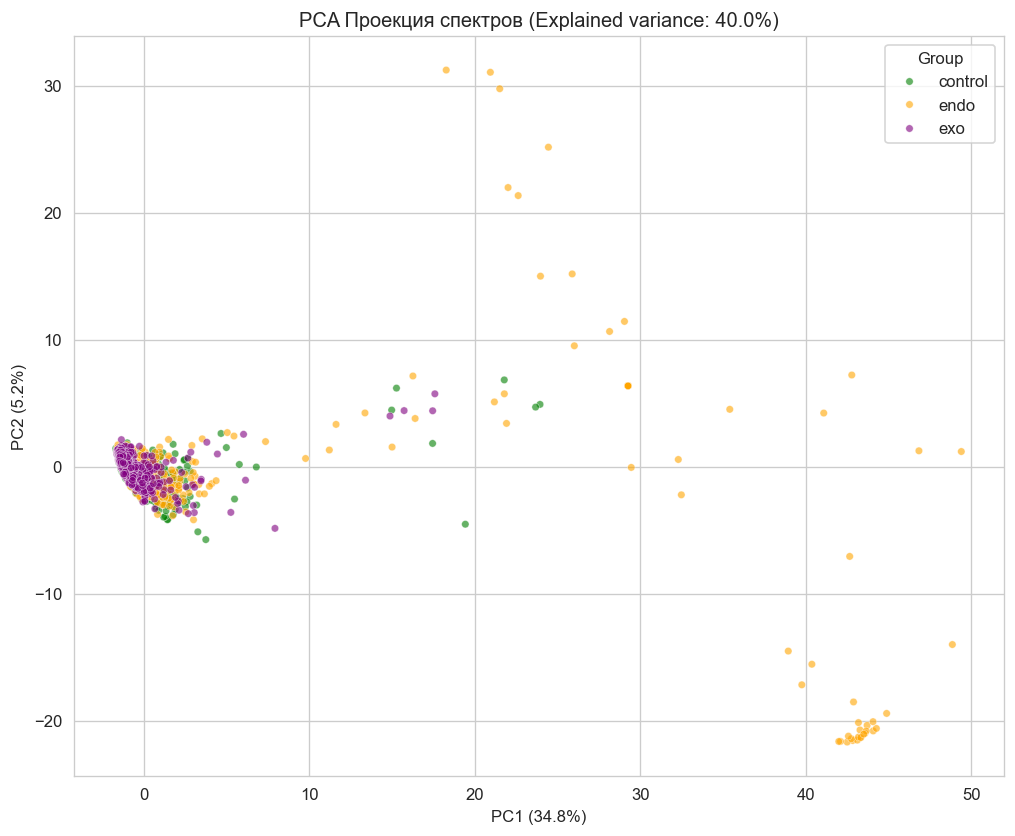

In [36]:
df = pd.read_csv('clean_center2900.csv')

meta_cols = ['file_id', 'target', 'region', 'X', 'Y']
wave_cols = [c for c in df.columns if c not in meta_cols]

meta_df = df[meta_cols].copy()
spectra_matrix = df[wave_cols].values
waves = np.array(wave_cols, dtype=float)

def baseline_als(y, lam=10**5, p=0.01, niter=10):
    L = len(y)
    D = sparse.diags([1,-2,1],[0,-1,-2], shape=(L,L-2))
    D = lam * D.dot(D.transpose())
    w = np.ones(L)
    for i in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        Z = W + D
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1-p) * (y < z)
    return z

def preprocess_spectra(spectra):
    n_samples = spectra.shape[0]
    processed = np.zeros_like(spectra)
    
    spectra_clean = np.nan_to_num(spectra, nan=0.0, posinf=0.0, neginf=0.0)
    
    for i in tqdm(range(n_samples)):
        y = spectra_clean[i, :]
        if np.all(y == 0): continue
            
        baseline = baseline_als(y, lam=10**5, p=0.01)
        y_corrected = y - baseline
        
        processed[i, :] = savgol_filter(y_corrected, window_length=11, polyorder=3, mode='nearest')
        
    mean_vals = processed.mean(axis=1, keepdims=True)
    std_vals = processed.std(axis=1, keepdims=True)
    std_vals[std_vals == 0] = 1 
    
    processed_snv = (processed - mean_vals) / std_vals
    processed_snv = np.nan_to_num(processed_snv, nan=0.0)
    
    return processed_snv

spectra_processed = preprocess_spectra(spectra_matrix)

df_clean = meta_df.copy()
df_clean[wave_cols] = spectra_processed
df_clean.to_csv('ready_for_ML_2900.csv', index=False)

plt.figure(figsize=(14, 6))
colors = {'control': 'green', 'endo': 'orange', 'exo': 'purple', 'unknown': 'gray'}

for target in ['control', 'endo', 'exo']:
    class_mask = meta_df['target'] == target
    if not class_mask.any(): continue 
        
    class_spectra = spectra_processed[class_mask]
    mean_spectrum = class_spectra.mean(axis=0)
    
    std_spectrum = class_spectra.std(axis=0) * 0.1 
    
    plt.plot(waves, mean_spectrum, label=f'{target.upper()} (n={len(class_spectra)})', 
             color=colors.get(target, 'blue'), linewidth=2)
    plt.fill_between(waves, mean_spectrum - std_spectrum, mean_spectrum + std_spectrum, 
                     color=colors.get(target, 'blue'), alpha=0.15)

plt.title("Усредненные Рамановские спектры по группам (Preprocessed)")
plt.xlabel("Raman shift (cm-1)")
plt.ylabel("Normalized Intensity")
plt.legend()
plt.show()

if ('control' in meta_df['target'].values) and ('endo' in meta_df['target'].values) and ('exo' in meta_df['target'].values):
    mean_control = spectra_processed[meta_df['target'] == 'control'].mean(axis=0)
    mean_endo = spectra_processed[meta_df['target'] == 'endo'].mean(axis=0)
    mean_exo = spectra_processed[meta_df['target'] == 'exo'].mean(axis=0)

    plt.figure(figsize=(14, 4))
    plt.plot(waves, mean_endo - mean_control, label='Endo - Control', color='orange', linewidth=1.5)
    plt.plot(waves, mean_exo - mean_control, label='Exo - Control', color='purple', linewidth=1.5)

    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title("Разностный спектр: поиск информативных пиков (отклонение от Control)")
    plt.xlabel("Raman shift (cm-1)")
    plt.ylabel("Difference in Intensity")
    plt.legend()
    plt.show()
else:
    print("Невозможно построить разностный график: отсутствуют некоторые классы.")

pca = PCA(n_components=2)

sample_indices = []
for target in ['control', 'endo', 'exo']:
    idx = np.where(meta_df['target'] == target)[0]
    if len(idx) > 0:
        sample_indices.extend(np.random.choice(idx, min(2000, len(idx)), replace=False))

sample_indices = np.array(sample_indices)

pca_result = pca.fit_transform(spectra_processed[sample_indices])
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['target'] = meta_df.iloc[sample_indices]['target'].values

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='target', data=pca_df, palette=colors, alpha=0.6, s=20)
plt.title(f"PCA Проекция спектров (Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title='Group')
plt.show()

Accuracy: 0.6101
F1 Macro: 0.6012

              precision    recall  f1-score   support

     control       0.54      0.60      0.57      3150
        endo       0.53      0.57      0.55      4165
         exo       0.72      0.64      0.68      5775

    accuracy                           0.61     13090
   macro avg       0.60      0.61      0.60     13090
weighted avg       0.62      0.61      0.61     13090



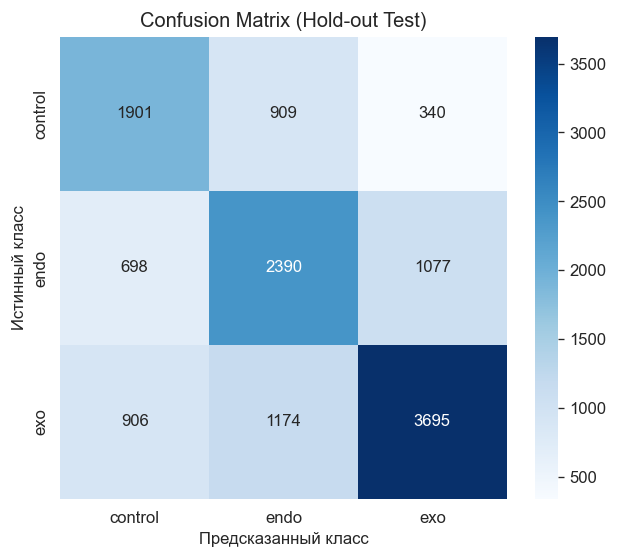

       Wave  Importance
336  1289.9         323
471  1434.5         277
337  1291.0         262
334  1287.7         209
344  1298.4         209
191  1134.6         201
472  1435.5         196
192  1135.6         186
479  1443.0         182
190  1133.5         169


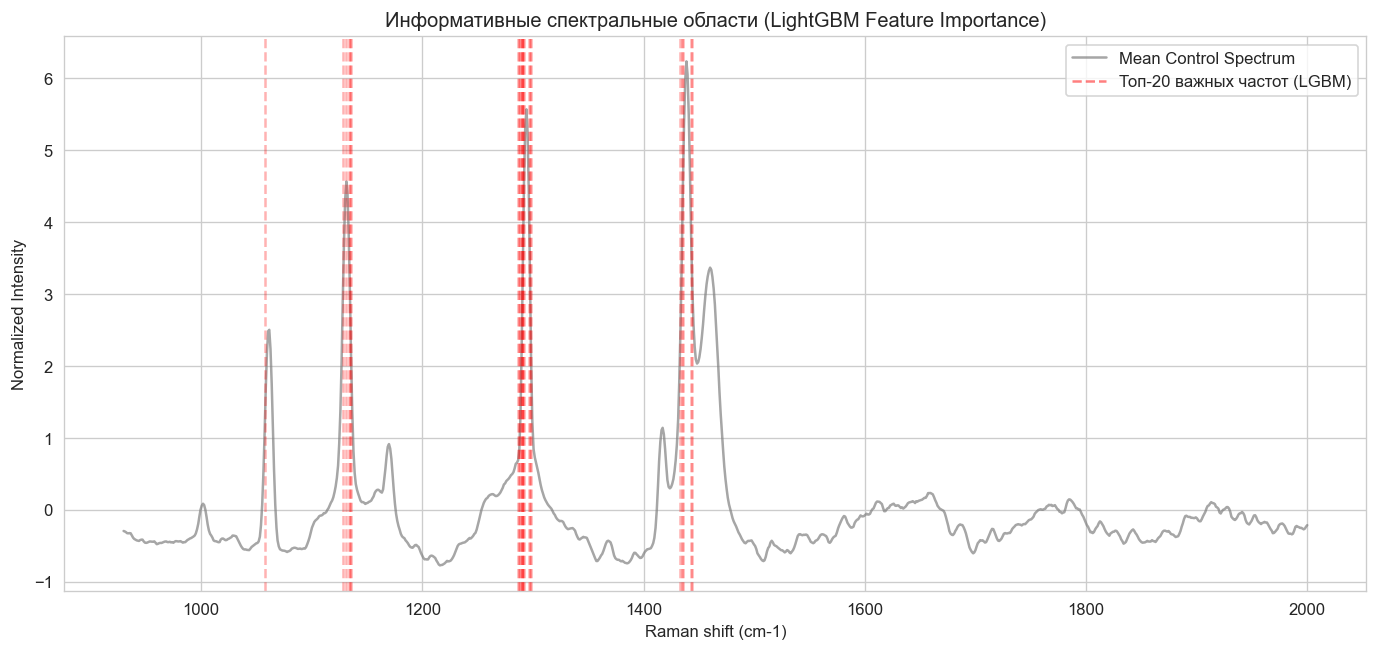

In [37]:
df = pd.read_csv('ready_for_ML_1500.csv')

meta_cols = ['file_id', 'target', 'region', 'X', 'Y']
wave_cols = [c for c in df.columns if c not in meta_cols]

X = df[wave_cols].values
y_text = df['target'].values
groups = df['file_id'].values

le = LabelEncoder()
y = le.fit_transform(y_text)
classes = le.classes_

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, y_train, groups_train = X[train_idx], y[train_idx], groups[train_idx]
X_test, y_test, groups_test = X[test_idx], y[test_idx], groups[test_idx]

lgb_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'feature_fraction': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

model = lgb.LGBMClassifier(**lgb_params, n_estimators=300)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Accuracy: {acc:.4f}")
print(f"F1 Macro: {f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=classes))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix (Hold-out Test)")
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

importances = model.feature_importances_
waves_float = np.array(wave_cols, dtype=float)

feat_df = pd.DataFrame({
    'Wave': waves_float,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_df.head(10))

plt.figure(figsize=(14, 6))

mean_control = X[y == le.transform(['control'])[0]].mean(axis=0)
plt.plot(waves_float, mean_control, color='gray', label='Mean Control Spectrum', alpha=0.7)

top_features = feat_df.head(20)['Wave'].values
for val in top_features:
    plt.axvline(x=val, color='red', alpha=0.3, linestyle='--', linewidth=1.5)

plt.axvline(x=top_features[0], color='red', alpha=0.5, linestyle='--', label='Топ-20 важных частот (LGBM)')

plt.title("Информативные спектральные области (LightGBM Feature Importance)")
plt.xlabel("Raman shift (cm-1)")
plt.ylabel("Normalized Intensity")
plt.legend()
plt.show()

File-level Accuracy: 0.8333
File-level F1 Macro: 0.8278

              precision    recall  f1-score   support

     control       0.75      1.00      0.86         6
        endo       0.83      0.71      0.77         7
         exo       0.90      0.82      0.86        11

    accuracy                           0.83        24
   macro avg       0.83      0.84      0.83        24
weighted avg       0.84      0.83      0.83        24



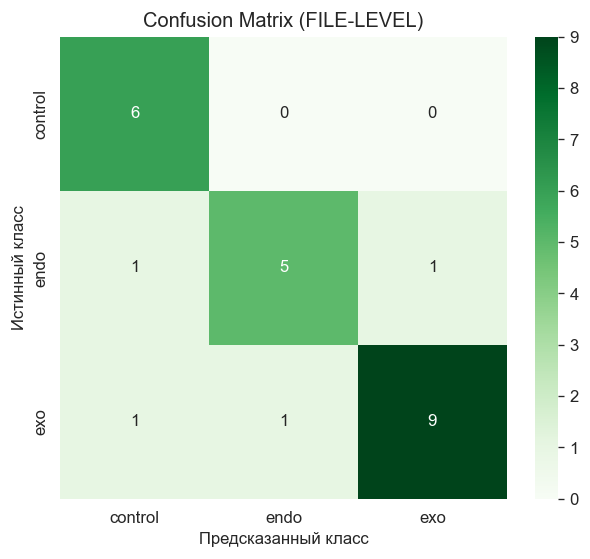

In [38]:
y_prob = model.predict_proba(X_test)

df_results = pd.DataFrame(y_prob, columns=classes)
df_results['file_id'] = groups_test
df_results['true_label'] = le.inverse_transform(y_test)

file_predictions = df_results.groupby(['file_id', 'true_label']).mean().reset_index()

file_predictions['pred_label'] = file_predictions[classes].idxmax(axis=1)

file_y_true = file_predictions['true_label']
file_y_pred = file_predictions['pred_label']

acc_file = accuracy_score(file_y_true, file_y_pred)
f1_file = f1_score(file_y_true, file_y_pred, average='macro')

print(f"File-level Accuracy: {acc_file:.4f}")
print(f"File-level F1 Macro: {f1_file:.4f}\n")
print(classification_report(file_y_true, file_y_pred))

cm_file = confusion_matrix(file_y_true, file_y_pred, labels=classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_file, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix (FILE-LEVEL)")
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

Tuned File-level Accuracy: 0.7500
Tuned File-level F1 Macro: 0.7410

              precision    recall  f1-score   support

     control       0.83      0.83      0.83         6
        endo       0.57      0.57      0.57         7
         exo       0.82      0.82      0.82        11

    accuracy                           0.75        24
   macro avg       0.74      0.74      0.74        24
weighted avg       0.75      0.75      0.75        24



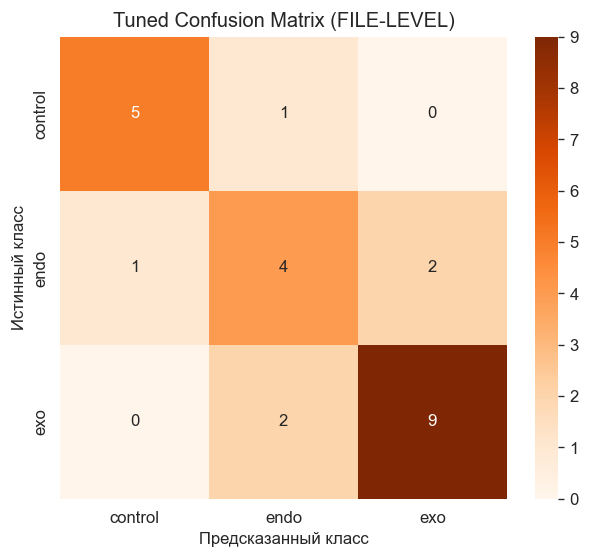

In [39]:
tuned_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.01,      
    'num_leaves': 31,
    'max_depth': 5,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.5,
    'reg_lambda': 1.0,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

model_tuned = lgb.LGBMClassifier(**tuned_params, n_estimators=1000)

model_tuned.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

y_prob_tuned = model_tuned.predict_proba(X_test)
df_res_tuned = pd.DataFrame(y_prob_tuned, columns=classes)
df_res_tuned['file_id'] = groups_test
df_res_tuned['true_label'] = le.inverse_transform(y_test)

file_pred_tuned = df_res_tuned.groupby(['file_id', 'true_label']).mean().reset_index()
file_pred_tuned['pred_label'] = file_pred_tuned[classes].idxmax(axis=1)

y_true_t = file_pred_tuned['true_label']
y_pred_t = file_pred_tuned['pred_label']

acc_t = accuracy_score(y_true_t, y_pred_t)
f1_t = f1_score(y_true_t, y_pred_t, average='macro')

print(f"Tuned File-level Accuracy: {acc_t:.4f}")
print(f"Tuned File-level F1 Macro: {f1_t:.4f}\n")
print(classification_report(y_true_t, y_pred_t))

cm_tuned = confusion_matrix(y_true_t, y_pred_t, labels=classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes)
plt.title("Tuned Confusion Matrix (FILE-LEVEL)")
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

LIPID File-level Accuracy: 0.7917
LIPID File-level F1 Macro: 0.7778

              precision    recall  f1-score   support

     control       0.88      0.70      0.78        10
        endo       0.67      0.67      0.67         6
         exo       0.80      1.00      0.89         8

    accuracy                           0.79        24
   macro avg       0.78      0.79      0.78        24
weighted avg       0.80      0.79      0.79        24



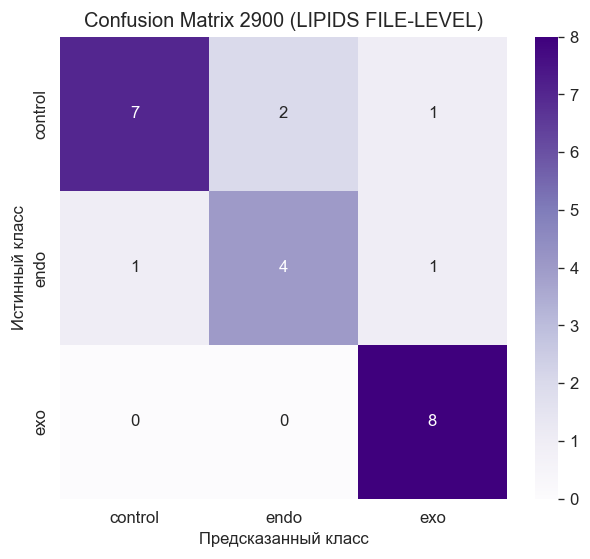

       Wave  Importance
464  2878.7         197
470  2882.3         178
463  2878.1         130
469  2881.7         120
471  2882.9         109


In [40]:
df_29 = pd.read_csv('ready_for_ML_2900.csv')

meta_cols = ['file_id', 'target', 'region', 'X', 'Y']
wave_cols_29 = [c for c in df_29.columns if c not in meta_cols]

X_29 = df_29[wave_cols_29].values
y_text_29 = df_29['target'].values
groups_29 = df_29['file_id'].values

le_29 = LabelEncoder()
y_29 = le_29.fit_transform(y_text_29)
classes_29 = le_29.classes_

gss_29 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_29, test_idx_29 = next(gss_29.split(X_29, y_29, groups_29))

X_train_29, y_train_29, groups_train_29 = X_29[train_idx_29], y_29[train_idx_29], groups_29[train_idx_29]
X_test_29, y_test_29, groups_test_29 = X_29[test_idx_29], y_29[test_idx_29], groups_29[test_idx_29]

lgb_params_29 = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'feature_fraction': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

model_29 = lgb.LGBMClassifier(**lgb_params_29, n_estimators=300)
model_29.fit(
    X_train_29, y_train_29,
    eval_set=[(X_test_29, y_test_29)],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
)

y_prob_29 = model_29.predict_proba(X_test_29)

df_res_29 = pd.DataFrame(y_prob_29, columns=classes_29)
df_res_29['file_id'] = groups_test_29
df_res_29['true_label'] = le_29.inverse_transform(y_test_29)

file_pred_29 = df_res_29.groupby(['file_id', 'true_label']).mean().reset_index()
file_pred_29['pred_label'] = file_pred_29[classes_29].idxmax(axis=1)

y_true_29 = file_pred_29['true_label']
y_pred_final_29 = file_pred_29['pred_label']

acc_29 = accuracy_score(y_true_29, y_pred_final_29)
f1_29 = f1_score(y_true_29, y_pred_final_29, average='macro')

print(f"LIPID File-level Accuracy: {acc_29:.4f}")
print(f"LIPID File-level F1 Macro: {f1_29:.4f}\n")
print(classification_report(y_true_29, y_pred_final_29))

cm_29 = confusion_matrix(y_true_29, y_pred_final_29, labels=classes_29)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_29, annot=True, fmt='d', cmap='Purples', xticklabels=classes_29, yticklabels=classes_29)
plt.title("Confusion Matrix 2900 (LIPIDS FILE-LEVEL)")
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

importances_29 = model_29.feature_importances_
waves_float_29 = np.array(wave_cols_29, dtype=float)
feat_df_29 = pd.DataFrame({'Wave': waves_float_29, 'Importance': importances_29}).sort_values(by='Importance', ascending=False)
print(feat_df_29.head(5))

In [41]:
ensemble_df.to_csv('final_predictions.csv', index=False)

In [42]:
import joblib

try:
    joblib.dump(model_tuned, 'model_1500.pkl')
except NameError:
    joblib.dump(model, 'model_1500.pkl')

joblib.dump(wave_cols, 'cols_1500.pkl')
joblib.dump(model_29, 'model_2900.pkl')

joblib.dump(wave_cols_29, 'cols_2900.pkl')

['cols_2900.pkl']